In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("jp_morgan.csv")

In [4]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,06-08-2023,33759.69057,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,08-11-2023,69319.19933,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,15-05-2024,42831.48483,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,30-04-2023,70903.79697,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,16-02-2023,21948.97355,113405.32820,0.380675,411,13


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [6]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [7]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='object')

In [9]:
df['TransactionAmount'] = df['TransactionAmount'].replace('[₹,]', '', regex=True).astype(float)

In [12]:
df['AccountBalance'] = df['AccountBalance'].replace('[₹,]', '', regex=True).astype(float)

In [14]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True)

In [16]:
df['TransactionType'] = df['TransactionType'].str.lower().str.strip()
df['AccountType'] = df['AccountType'].str.lower().str.strip()
df['Region'] = df['Region'].str.lower().str.strip()

In [17]:
df = df.drop_duplicates()

In [19]:
df['month'] = df['TransactionDate'].dt.to_period('M')

In [20]:
monthly = df.groupby(['month', 'TransactionType'])['TransactionAmount'].sum().unstack()

monthly.head()

TransactionType,deposit,payment,transfer,withdrawal
month,,,,
2023-01,586442.42703,892403.329063,511503.904434,815781.122358
2023-02,788091.35844,896472.509573,641396.528880,439855.688290
2023-03,568405.45070,621706.357696,439425.289570,845856.681975
2023-04,593836.81001,712652.450490,519042.113963,883698.507661
2023-05,729309.61573,633500.534446,818742.047450,415485.163630


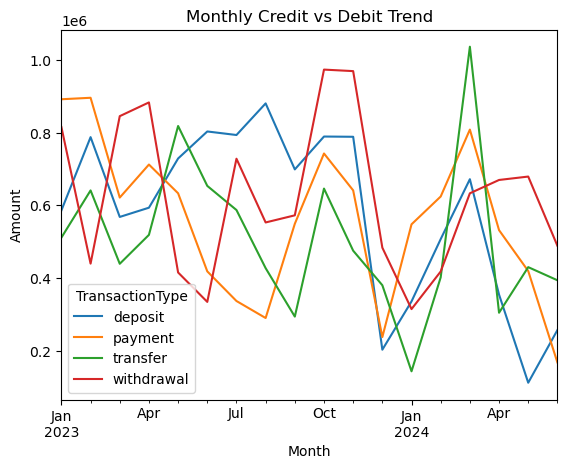

In [21]:
import matplotlib.pyplot as plt

monthly.plot()
plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

In [22]:
account_summary = df.groupby('AccountID')['TransactionAmount'].sum()

top_accounts = account_summary.sort_values(ascending=False).head(10)
bottom_accounts = account_summary.sort_values().head(10)

top_accounts

AccountID
ACC42710    539494.876440
ACC45907    532556.635574
ACC81631    483854.558670
ACC32627    471468.023823
ACC18140    458219.210460
ACC95774    453488.129360
ACC55331    448188.410346
ACC29477    443067.484857
ACC29646    439477.177961
ACC22036    437626.170698
Name: TransactionAmount, dtype: float64

In [23]:
bottom_accounts

AccountID
ACC12334    15159.688345
ACC50439    24088.157284
ACC65144    30425.901148
ACC28305    32162.348245
ACC43771    32819.585640
ACC49180    37023.532950
ACC46655    37365.268690
ACC30146    42545.848430
ACC39482    42831.484830
ACC87006    42903.165440
Name: TransactionAmount, dtype: float64

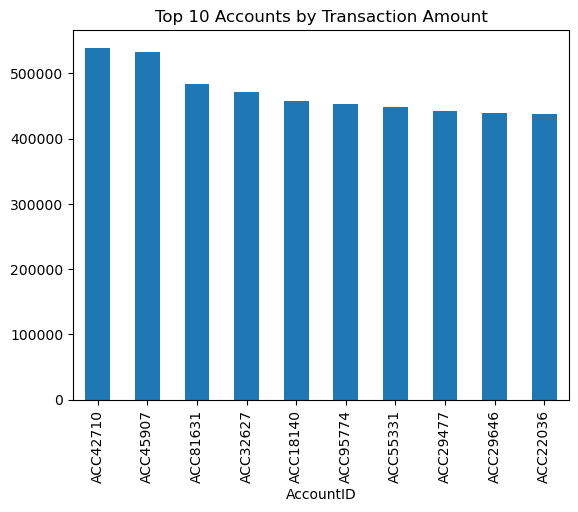

In [24]:
top_accounts.plot(kind='bar')
plt.title("Top 10 Accounts by Transaction Amount")
plt.show()

In [25]:
df = df.sort_values(['AccountID', 'TransactionDate'])

df['gap'] = df.groupby('AccountID')['TransactionDate'].diff().dt.days

In [26]:
dormant_accounts = df[df['gap'] > 60]

dormant_accounts.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,month,gap
764,63,CUST4373,ACC10996,credit,deposit,Savings Account,Firm B,south,Manager 1,2023-07-01,81608.80093,67810.12401,0.505365,694,103,2023-07,161.0
113,106,CUST1547,ACC10996,credit,deposit,Personal Loan,Firm C,north,Manager 4,2023-10-19,92323.65567,39827.55468,0.672591,768,198,2023-10,110.0
401,196,CUST3778,ACC11062,credit,transfer,Home Loan,Firm E,north,Manager 4,2023-08-22,103375.34420,51672.12356,0.813273,341,32,2023-08,103.0
354,15,CUST4669,ACC11062,loan,withdrawal,Mutual Fund,Firm E,west,Manager 1,2023-12-25,35748.04389,105604.12180,0.142407,304,16,2023-12,125.0
362,41,CUST7855,ACC11188,savings,payment,Personal Loan,Firm B,north,Manager 1,2023-08-17,61343.12824,110972.96240,0.306461,329,177,2023-08,163.0


In [27]:
df['year'] = df['TransactionDate'].dt.year

yearly = df.groupby(['year', 'TransactionType'])['TransactionAmount'].sum().unstack()

yearly

TransactionType,deposit,payment,transfer,withdrawal
year,,,,
2023,8.225787e+06,6.974170e+06,6.395137e+06,8.017619e+06
2024,2.238946e+06,3.100943e+06,2.711474e+06,3.205223e+06


In [28]:
freq = df.groupby('AccountID').size()
freq.head()

AccountID
ACC10117    1
ACC10996    4
ACC11062    4
ACC11188    3
ACC11285    6
dtype: int64

In [67]:
def activity(x):
    if x > 50:
        return "High"
    elif x >= 20:
        return "Medium"
    else:
        return "Low"

activity_level = freq.apply(activity)
activity_level.head()

AccountID
ACC10117    Low
ACC10996    Low
ACC11062    Low
ACC11188    Low
ACC11285    Low
dtype: object

In [68]:
avg_balance = df.groupby('AccountID')['AccountBalance'].mean()

In [69]:
total_volume = df.groupby('AccountID')['TransactionAmount'].sum()

In [70]:
profile = pd.DataFrame({
    'Frequency': freq,
    'ActivityLevel': activity_level,
    'AvgBalance': avg_balance,
    'TotalVolume': total_volume
})

profile.head()

,Frequency,ActivityLevel,AvgBalance,TotalVolume
AccountID,,,,
ACC10117,1,Low,90780.256640,56317.920060
ACC10996,4,Low,64046.568590,223757.534516
ACC11062,4,Low,62784.100737,265928.583340
ACC11188,3,Low,80558.926400,116557.954500
ACC11285,6,Low,95745.546255,373189.528410


In [71]:
high_inflow = profile.sort_values(by='TotalVolume', ascending=False).head(10)

In [72]:
hf_lb = profile[(profile['Frequency'] > 50) & (profile['AvgBalance'] < 5000)]

In [73]:
low_balance = profile[profile['AvgBalance'] <= 1000]

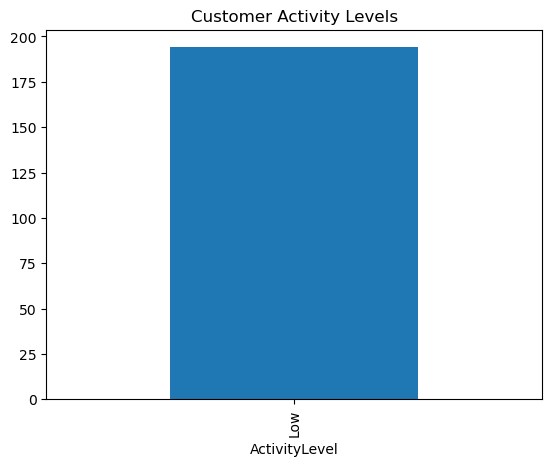

In [74]:
profile['ActivityLevel'].value_counts().plot(kind='bar')
plt.title("Customer Activity Levels")
plt.show()

In [75]:
large_withdrawals = df[
    (df['TransactionType'] == 'debit') & 
    (df['TransactionAmount'] > 50000)
]

large_withdrawals.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,month,gap,year


In [76]:
volatility = df.groupby('AccountID')['AccountBalance'].std()

volatility.head()

AccountID
ACC10117             NaN
ACC10996    30390.798000
ACC11062    37598.383500
ACC11188    33781.833882
ACC11285    42139.172552
Name: AccountBalance, dtype: float64

In [77]:
high_volatility = volatility.sort_values(ascending=False).head(10)
high_volatility

AccountID
ACC39529    87925.613732
ACC78589    74986.233658
ACC49774    67777.809369
ACC28612    59940.470436
ACC57516    57794.003514
ACC51971    56709.662822
ACC33287    55392.907529
ACC74656    55037.331771
ACC66190    52142.885192
ACC90887    51988.111482
Name: AccountBalance, dtype: float64

In [78]:
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['TransactionAmount'] < Q1 - 1.5 * IQR) | 
    (df['TransactionAmount'] > Q3 + 1.5 * IQR)
]

outliers.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,month,gap,year
97,67,CUST6391,ACC26940,current,payment,Home Loan,Firm A,south,Manager 4,2023-03-16,-25964.94612,94822.29734,0.639771,315,209,2023-03,10.0,2023
129,161,CUST4373,ACC41829,current,payment,Savings Account,Firm A,north,Manager 3,2024-03-22,135972.34390,42302.00951,-0.368537,469,175,2024-03,NaN,2024
701,191,CUST6837,ACC46655,current,deposit,Mutual Fund,Firm E,west,Manager 2,2024-06-16,-29563.97803,49810.32678,0.517913,466,150,2024-06,131.0,2024
53,178,CUST1189,ACC50439,savings,deposit,Savings Account,Firm D,east,Manager 1,2024-06-16,-60979.07348,57916.06101,0.160988,655,17,2024-06,103.0,2024
659,21,CUST1644,ACC77533,credit,payment,Personal Loan,Firm D,south,Manager 4,2023-12-24,-30826.73980,68006.03943,0.488742,678,42,2023-12,59.0,2023


In [79]:
risky_accounts = set(large_withdrawals['AccountID']) | set(outliers['AccountID'])
len(risky_accounts)

9

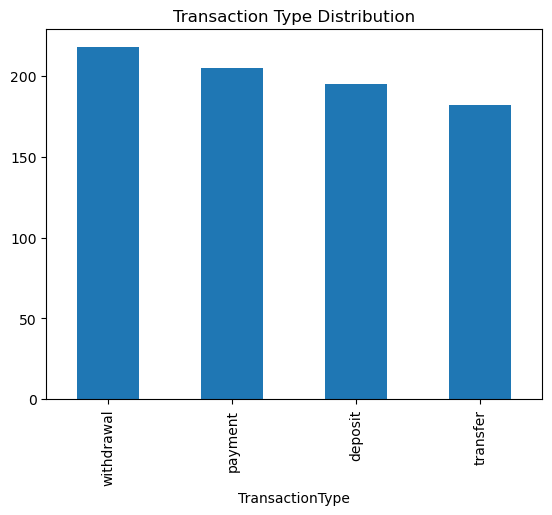

In [80]:
df['TransactionType'].value_counts().plot(kind='bar')
plt.title("Transaction Type Distribution")
plt.show()

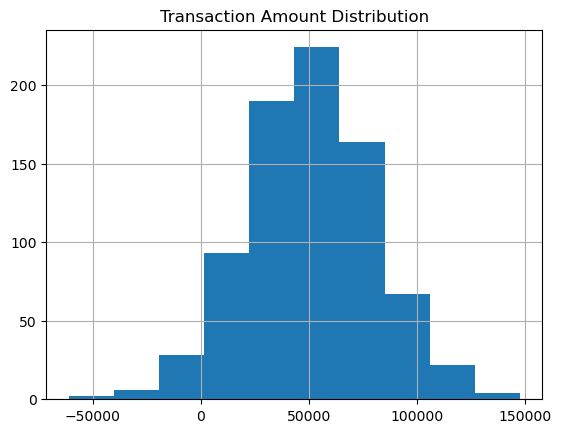

In [81]:
df['TransactionAmount'].hist()
plt.title("Transaction Amount Distribution")
plt.show()

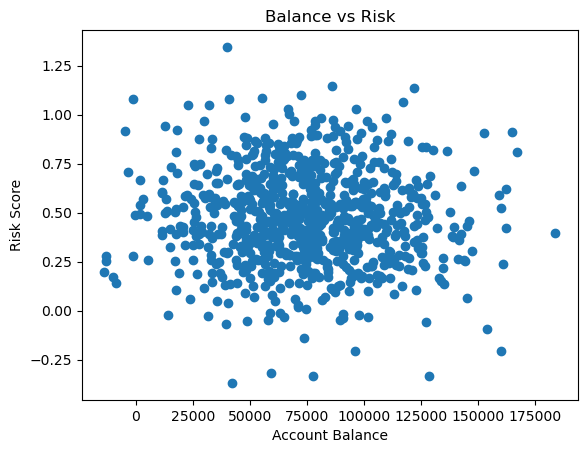

In [83]:
plt.scatter(df['AccountBalance'], df['RiskScore'])
plt.xlabel("Account Balance")
plt.ylabel("Risk Score")
plt.title("Balance vs Risk")
plt.show()

In [93]:
freq = df.groupby('AccountID').size()

In [94]:
high_accounts = freq[freq >= 5].index
low_accounts = freq[freq <= 2].index

In [95]:
print(len(high_accounts))
print(len(low_accounts))

75
46


In [96]:
high_balance = df[df['AccountID'].isin(high_accounts)]['AccountBalance']
low_balance = df[df['AccountID'].isin(low_accounts)]['AccountBalance']

In [97]:
high_balance = high_balance.dropna()
low_balance = low_balance.dropna()

In [98]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_balance, low_balance)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.4690107519286387
P-value: 0.6392495061422514
